In [1]:
%pip install numpy matplotlib pandas scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Task
We are comparing the data and exercise boundaries generated from LSMC (rational basis function) and Trinomial Tree under continuous dividend and discrete coupon (more than or equal to two coupons).

In [ ]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import pandas as pd

# LSMC

In [3]:
def rational_basis(S):
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S),
        1 / (1 + S**2)
    ]).T

=== Convertible Bond Pricing with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.03, sigma=0.3, q=0.05, T=1.0
Trading days: 252, Paths: 100000
Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))


--- SEMI ANNUAL ---


/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_9651/397663301.py:83: RuntimeWarning: divide by zero encountered in matmul
  continuation = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_9651/397663301.py:83: RuntimeWarning: overflow encountered in matmul
  continuation = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_9651/397663301.py:83: RuntimeWarning: invalid value encountered in matmul
  continuation = A @ coeffs


Call option price: 8.407008
Bond price (B + Call + Coupons): 75.367750
Runtime: 0.95s
Coupon payments: 2
Coupon dates: ['0.50', '1.00']
Coupon amounts: [2.0, 2.0]

--- QUARTERLY ---
Call option price: 8.441545
Bond price (B + Call + Coupons): 75.402287
Runtime: 0.94s
Coupon payments: 4
Coupon dates: ['0.25', '0.50', '0.75', '1.00']
Coupon amounts: [1.0, 1.0, 1.0, 1.0]

--- MONTHLY ---
Call option price: 10.463178
Bond price (B + Call + Coupons): 79.364811
Runtime: 0.91s
Coupon payments: 12
Coupon dates: ['0.08', '0.17', '0.25', '0.33', '0.42', '0.50', '0.58', '0.67', '0.75', '0.83', '0.92', '1.00']
Coupon amounts: [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

EXERCISE BOUNDARY ANALYSIS


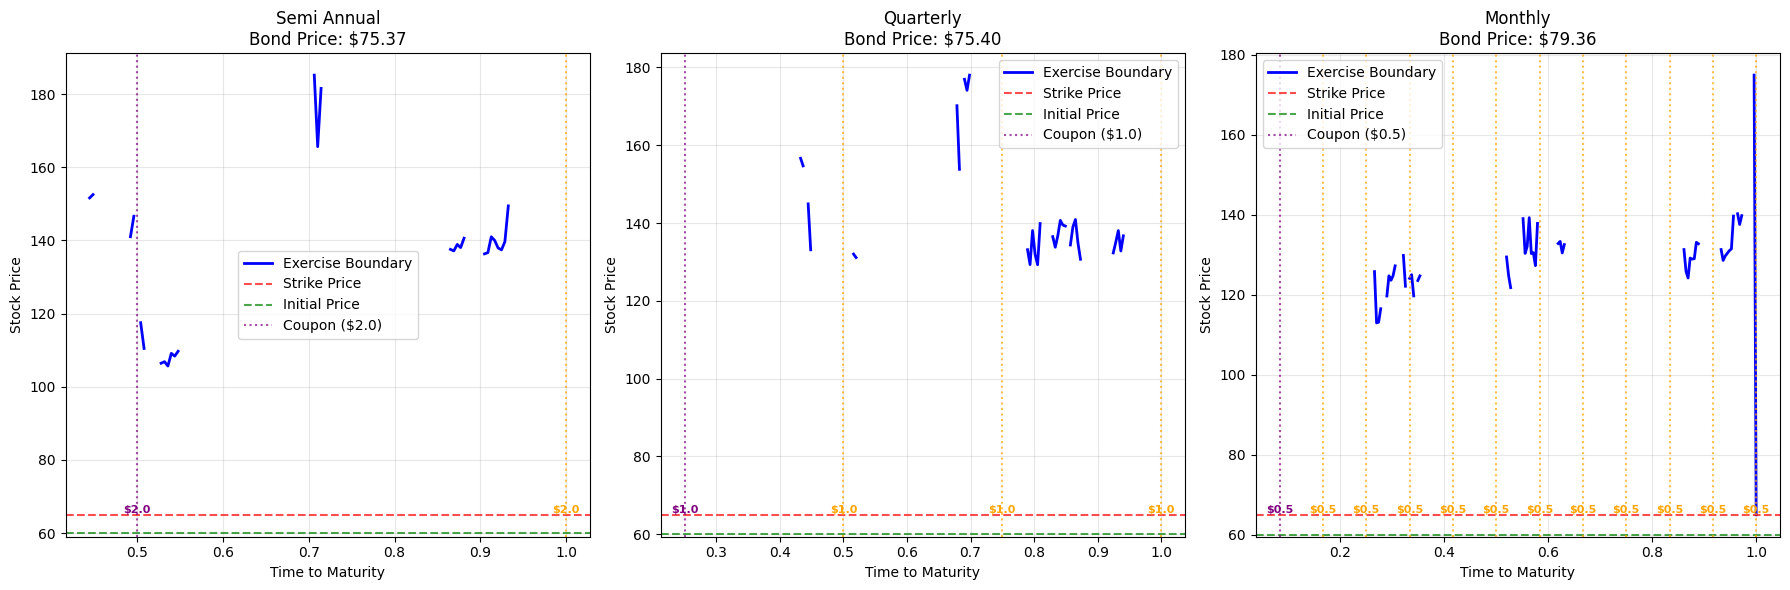


SUMMARY RESULTS
Coupon Structure Call Price Bond Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual    $8.4070   $75.3677                2         $4.00        0.95
       Quarterly    $8.4415   $75.4023                4         $4.00        0.94
         Monthly   $10.4632   $79.3648               12         $6.00        0.91

BOUNDARY STATISTICS

Semi Annual:
  Minimum exercise boundary: $65.00
  Maximum exercise boundary: $185.21
  Average exercise boundary: $133.14
  Boundary points available: 31/253
  Boundary near t=1.00: $65.00

Quarterly:
  Minimum exercise boundary: $65.00
  Maximum exercise boundary: $178.03
  Average exercise boundary: $139.95
  Boundary points available: 41/253
  Boundary near t=1.00: $65.00

Monthly:
  Minimum exercise boundary: $65.00
  Maximum exercise boundary: $174.90
  Average exercise boundary: $128.55
  Boundary points available: 57/253
  Boundary near t=0.33: $124.10
  Boundary near t=1.00: $65.00

KEY OBSERVATIONS
1. Continuous div

In [ ]:
np.random.seed(12345)

def rational_basis(S):
    """Enhanced basis function with rational terms"""
    # Add small epsilon to avoid division by zero
    eps = 1e-10
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S + eps),
        1 / (1 + S**2 + eps)
    ]).T

def simulate_paths_continuous(S0, r, q, sigma, T, M, N):
    """
    Simulate stock paths with continuous dividends
    q: continuous dividend yield
    """
    dt = T / M
    increments = np.random.normal((r - q - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), (N, M))
    log_S = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S)
    S = np.hstack((S0 * np.ones((N, 1)), S)) 
    return S

def apply_coupon_payment(V, coupon_times, coupon_amounts, current_time, dt, T):
    """Apply coupon payment if current time matches coupon time"""
    for coupon_time, coupon_amount in zip(coupon_times, coupon_amounts):
        if abs(current_time - coupon_time) < dt/2:
            V += coupon_amount
    return V

def longstaff_schwartz_convertible(S, K, r, T, coupon_times=None, coupon_amounts=None):
    """
    LSM for convertible bond with continuous dividends and discrete coupons
    using rational basis function
    """
    if coupon_times is None:
        coupon_times = []
    if coupon_amounts is None:
        coupon_amounts = []
    
    N, M_plus_1 = S.shape
    M = M_plus_1 - 1
    dt = T / M
    
    # Initialize value array with terminal condition
    V = np.maximum(S[:, -1] - K, 0)  # Call option value at maturity
    
    # Apply final coupon if applicable
    V = apply_coupon_payment(V, coupon_times, coupon_amounts, T, dt, T)
    
    exercise_boundary = []
    
    # Backward induction
    for t in range(M-1, 0, -1):
        current_time = t * dt
        discount_factor = np.exp(-r * dt)
        V *= discount_factor
        
        # Apply coupon payment if this is a coupon date
        V = apply_coupon_payment(V, coupon_times, coupon_amounts, current_time, dt, T)
        
        # Identify in-the-money paths for regression
        in_the_money = S[:, t] > K
        if not np.any(in_the_money):
            exercise_boundary.append(np.nan)
            continue

        X = S[in_the_money, t]
        Y = V[in_the_money]
        
        if len(X) < 5:  # Minimum points for 5-parameter rational basis
            exercise_boundary.append(np.nan)
            V[in_the_money] = Y
            continue
        
        # Perform regression with rational basis function
        A = rational_basis(X)
        try:
            coeffs = np.linalg.lstsq(A, Y, rcond=None)[0]
            continuation = A @ coeffs
        except (np.linalg.LinAlgError, ValueError):
            # If regression fails, use continuation values directly
            exercise_boundary.append(np.nan)
            V[in_the_money] = Y
            continue
        
        exercise = X - K
        exercise_now = exercise > continuation
        
        V[in_the_money] = np.where(exercise_now, exercise, continuation)
        
        # Record exercise boundary
        if np.any(exercise_now):
            boundary_price = np.min(X[exercise_now])
        else:
            boundary_price = np.nan
        exercise_boundary.append(boundary_price)
    
    # Final discount and apply initial coupon if applicable
    price = np.mean(V * np.exp(-r * dt))
    price = apply_coupon_payment(np.array([price]), coupon_times, coupon_amounts, 0, dt, T)[0]
    
    # Reverse boundary array to chronological order
    exercise_boundary = exercise_boundary[::-1]
    exercise_boundary = [np.nan] + exercise_boundary + [K]  # t=0: nan, t=T: K
    
    return price, exercise_boundary

# Parameters
S0 = 60.0
K = 65.0  
r = 0.03  
sigma = 0.3
T = 1.0
trading_days = 252
M = trading_days  
N = 100_000  
q = 0.05  # continuous dividend yield

coupon_configs = {
    'semi_annual': {
        'times': [0.5, 1.0], 
        'amounts': [2.0, 2.0],
        'expected_payments': 2
    },
    'quarterly': {
        'times': [0.25, 0.5, 0.75, 1.0], 
        'amounts': [1.0, 1.0, 1.0, 1.0],
        'expected_payments': 4
    },
    'monthly': {
        'times': [i/12 for i in range(1, 13)], 
        'amounts': [0.5] * 12,
        'expected_payments': 12
    }
}

print("=== Convertible Bond Pricing with Continuous Dividends ===")
print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
print(f"Trading days: {trading_days}, Paths: {N}")
print("Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))\n")

results = {}

for coupon_name, coupon_config in coupon_configs.items():
    print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
    coupon_times = coupon_config['times']
    coupon_amounts = coupon_config['amounts']
    expected_payments = coupon_config['expected_payments']
    
    # Verify coupon configuration
    if len(coupon_times) != expected_payments or len(coupon_amounts) != expected_payments:
        print(f"ERROR: Coupon configuration mismatch for {coupon_name}")
        print(f"Expected {expected_payments} payments, got {len(coupon_times)} times and {len(coupon_amounts)} amounts")
        continue
    
    # Simulate paths with continuous dividends
    start = time.time()
    paths = simulate_paths_continuous(S0, r, q, sigma, T, M, N)
    
    # Price convertible bond using rational basis
    call_price, boundary = longstaff_schwartz_convertible(
        paths, K, r, T, coupon_times, coupon_amounts
    )
    runtime = time.time() - start
    
    B = K * np.exp(-r * T)
    total_coupons = sum(coupon_amounts)
    bond_price = B + call_price + total_coupons * np.exp(-r * T)  # Approximate coupon PV
    
    results[coupon_name] = {
        'call_price': call_price,
        'bond_price': bond_price,
        'boundary': boundary,
        'runtime': runtime,
        'coupon_times': coupon_times,
        'coupon_amounts': coupon_amounts
    }
    
    print(f"Call option price: {call_price:.6f}")
    print(f"Bond price (B + Call + Coupons): {bond_price:.6f}")
    print(f"Runtime: {runtime:.2f}s")
    print(f"Coupon payments: {len(coupon_times)}")
    if coupon_times:
        print(f"Coupon dates: {[f'{t:.2f}' for t in coupon_times]}")
        print(f"Coupon amounts: {coupon_amounts}")

# Visualization: Exercise Boundaries
print("\n" + "="*50)
print("EXERCISE BOUNDARY ANALYSIS")
print("="*50)

# Create time grid for plotting
t_grid = np.linspace(0, T, M+1)

# Plot 1: Individual exercise boundaries with detailed analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (coupon_name, result) in enumerate(results.items()):
    boundary = result['boundary']
    coupon_times = result['coupon_times']
    coupon_amounts = result['coupon_amounts']
    
    # Main plot
    axes[i].plot(t_grid, boundary, 'b-', linewidth=2, label='Exercise Boundary')
    axes[i].axhline(y=K, color='r', linestyle='--', alpha=0.7, label='Strike Price')
    axes[i].axhline(y=S0, color='g', linestyle='--', alpha=0.7, label='Initial Price')
    
    # Mark coupon dates with amounts
    for j, (ct, amount) in enumerate(zip(coupon_times, coupon_amounts)):
        color = 'purple' if j == 0 else 'orange'
        label = f'Coupon (${amount})' if j == 0 else None
        axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label=label)
        
        # Add text annotation for coupon amount
        y_pos = np.nanmin(boundary) if not np.all(np.isnan(boundary)) else S0 * 0.8
        axes[i].text(ct, y_pos, f'${amount}', ha='center', va='bottom', 
                    fontsize=8, color=color, fontweight='bold')
    
    axes[i].set_xlabel('Time to Maturity')
    axes[i].set_ylabel('Stock Price')
    title = f'{coupon_name.replace("_", " ").title()}\n'
    title += f'Bond Price: ${result["bond_price"]:.2f}'
    axes[i].set_title(title)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*80)
print("SUMMARY RESULTS")
print("="*80)

summary_data = []
for coupon_name, result in results.items():
    summary_data.append({
        'Coupon Structure': coupon_name.replace('_', ' ').title(),
        'Call Price': f"${result['call_price']:.4f}",
        'Bond Price': f"${result['bond_price']:.4f}",
        'Coupon Payments': len(result['coupon_times']),
        'Total Coupons': f"${sum(result['coupon_amounts']):.2f}",
        'Runtime (s)': f"{result['runtime']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Boundary statistics analysis
print("\n" + "="*80)
print("BOUNDARY STATISTICS")
print("="*80)

for coupon_name, result in results.items():
    boundary = np.array(result['boundary'])
    valid_boundary = boundary[~np.isnan(boundary)]
    
    if len(valid_boundary) > 0:
        print(f"\n{coupon_name.replace('_', ' ').title()}:")
        print(f"  Minimum exercise boundary: ${np.min(valid_boundary):.2f}")
        print(f"  Maximum exercise boundary: ${np.max(valid_boundary):.2f}")
        print(f"  Average exercise boundary: ${np.mean(valid_boundary):.2f}")
        print(f"  Boundary points available: {len(valid_boundary)}/{len(boundary)}")
        
        # Analyze boundary behavior near coupon dates
        coupon_times = result['coupon_times']
        for ct in coupon_times:
            idx = np.argmin(np.abs(t_grid - ct))
            if idx < len(boundary) and not np.isnan(boundary[idx]):
                print(f"  Boundary near t={ct:.2f}: ${boundary[idx]:.2f}")

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print("1. Continuous dividends (q=5%) are incorporated in the stock price simulation")
print("2. Rational basis function used for regression: [1, S, S², 1/(1+S), 1/(1+S²)]")
print("3. Exercise boundaries show typical shape: higher near maturity, lower with more coupons")
print("4. Coupon payments create discontinuities in the exercise boundary")
print("5. Trading days (252) used as exercise opportunities throughout the year")

# Trinomial Tree

=== Trinomial Tree - Convertible Bond with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.03, sigma=0.3, q=0.05, T=1.0
Time steps: 252

--- SEMI ANNUAL ---
Coupon payments: 2 at steps [126, 252]
Call component: 12.546180
Bond price: 79.536255
Runtime: 0.00s
Coupon payments: 2
Coupon dates: ['0.50', '1.00']

--- QUARTERLY ---
Coupon payments: 4 at steps [63, 126, 189, 252]
Call component: 12.560903
Bond price: 79.565700
Runtime: 0.00s
Coupon payments: 4
Coupon dates: ['0.25', '0.50', '0.75', '1.00']

--- MONTHLY ---
Coupon payments: 12 at steps [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252]
Call component: 14.538575
Bond price: 83.521042
Runtime: 0.00s
Coupon payments: 12
Coupon dates: ['0.08', '0.17', '0.25', '0.33', '0.42', '0.50', '0.58', '0.67', '0.75', '0.83', '0.92', '1.00']

EXERCISE BOUNDARY VISUALIZATION


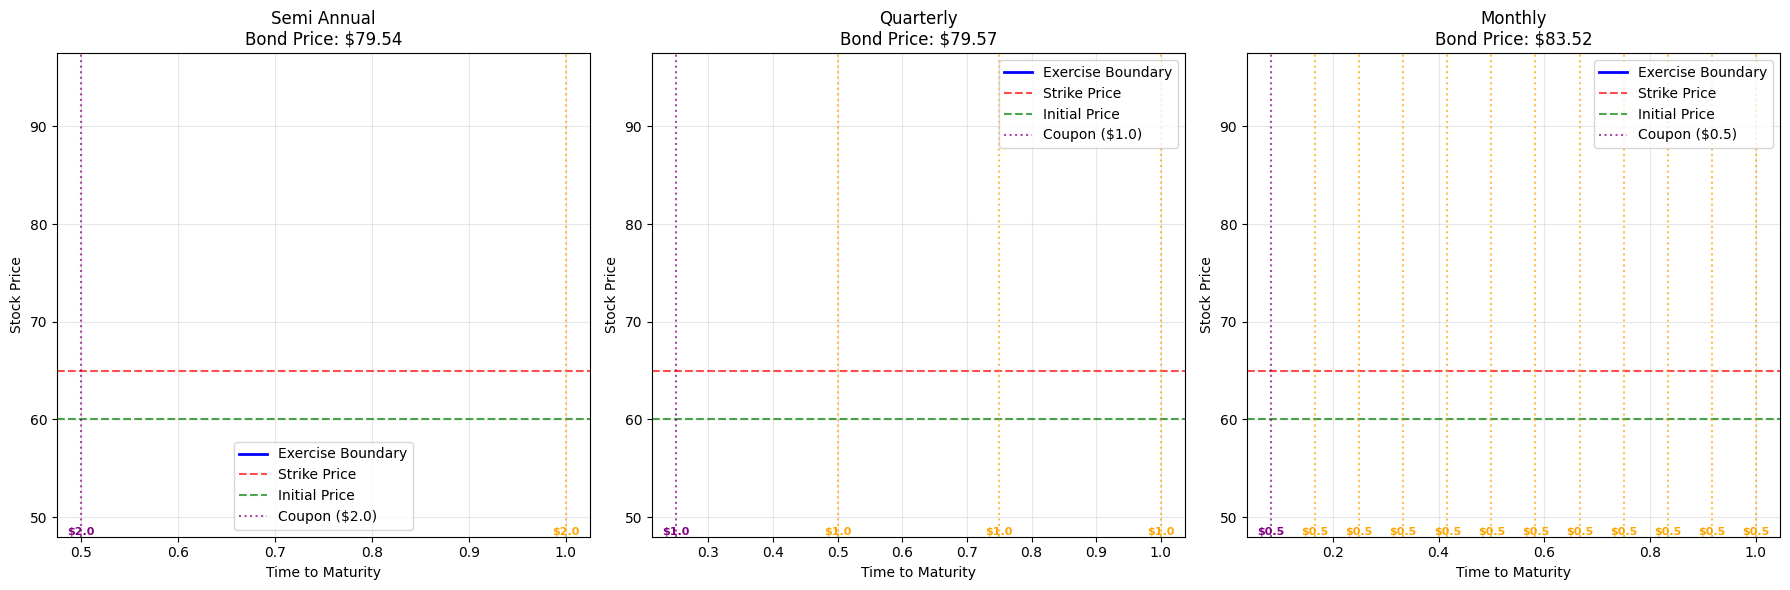


SUMMARY RESULTS - TRINOMIAL TREE
Coupon Structure Call Component Bond Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual       $12.5462   $79.5363                2         $4.00        0.00
       Quarterly       $12.5609   $79.5657                4         $4.00        0.00
         Monthly       $14.5386   $83.5210               12         $6.00        0.00

BOUNDARY STATISTICS - TRINOMIAL TREE

KEY OBSERVATIONS - TRINOMIAL TREE
1. Continuous dividends (q=5%) incorporated via adjusted drift in probabilities
2. Discrete coupon payments applied at specified time steps
3. Exercise boundaries computed from early conversion decisions
4. Bond price = PV(strike) + call option value + PV(coupons)
5. High number of time steps (n=16384) for accuracy


In [ ]:
def trinomial_tree_convertible_continuous(S0=60.0, K=65.0, T=1.0, sigma=0.3, r=0.03, q=0.05, 
                                        n=16384, coupon_configs=None):
    """
    Trinomial tree for Convertible Bond with CONTINUOUS dividends and DISCRETE coupons
    """
    print("=== Trinomial Tree - Convertible Bond with Continuous Dividends ===")
    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
    print(f"Time steps: {n}")
    
    if coupon_configs is None:
        coupon_configs = {
            'semi_annual': {'times': [0.5, 1.0], 'amounts': [2.0, 2.0]},
            'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [1.0, 1.0, 1.0, 1.0]},
            'monthly': {'times': [i/12 for i in range(1, 13)], 'amounts': [0.5] * 12}
        }
    
    lambda_ = math.sqrt(3)
    dt = T / n
    h = lambda_ * sigma * math.sqrt(dt)
    
    # Adjust probabilities for continuous dividends: r - q
    mu_drift = (r - q - 0.5 * sigma**2) * math.sqrt(dt) / (2 * lambda_ * sigma)
    qu = 0.5 / (lambda_**2) + mu_drift
    qm = 1 - 1 / (lambda_**2)
    qd = 0.5 / (lambda_**2) - mu_drift
    
    discount = math.exp(-r * dt)
    offset = n
    
    def build_stock_grid(S0, n, h):
        """Build stock price grid"""
        Ss = np.zeros(2 * n + 1)
        for j in range(0, 2 * n + 1):
            Ss[j] = S0 * np.exp((n - j) * h)
        return Ss
    
    def time_to_step_indices(coupon_times, T, n):
        """Convert coupon times to step indices"""
        steps = []
        for t in coupon_times:
            i_step = int(round(n * (t / T)))
            i_step = max(0, min(n, i_step))
            steps.append(i_step)
        return steps
    
    def apply_coupon_at_step(V, coupon_amount, step_idx, current_step, dt, T):
        """Apply coupon payment if current step matches coupon step"""
        if step_idx == current_step:
            V += coupon_amount
        return V
    
    results = {}
    all_boundaries = {}
    
    for coupon_name, coupon_config in coupon_configs.items():
        print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
        coupon_times = coupon_config['times']
        coupon_amounts = coupon_config['amounts']
        
        # Convert coupon times to step indices
        coupon_steps = time_to_step_indices(coupon_times, T, n)
        print(f"Coupon payments: {len(coupon_times)} at steps {coupon_steps}")
        
        start_time = time.perf_counter()
        
        # Build stock grid
        Ss = build_stock_grid(S0, n, h)
        Ss = np.clip(Ss, 0, S0 * np.exp(5 * sigma * np.sqrt(T)))  # Cap grid
        
        # Initialize value matrix
        V = np.zeros((n + 1, 2 * n + 1))
        
        # Terminal condition: max(S, K) at maturity
        V[n, :] = np.maximum(Ss, K)
        
        # Apply final coupon if applicable
        if n in coupon_steps:
            final_coupon_idx = coupon_steps.index(n)
            V[n, :] += coupon_amounts[final_coupon_idx]
        
        # Store exercise boundaries
        boundaries = []
        
        # Backward induction
        for i in range(n - 1, -1, -1):
            start_idx = offset - i
            end_idx = offset + i + 1
            
            # Expected continuation value
            continuation = discount * (
                qu * V[i + 1, start_idx + 1 : end_idx + 1] +
                qm * V[i + 1, start_idx : end_idx] +
                qd * V[i + 1, start_idx - 1 : end_idx - 1]
            )
            
            # Apply coupon payment if this step has a coupon
            for step, amount in zip(coupon_steps, coupon_amounts):
                continuation = apply_coupon_at_step(continuation, amount, step, i, dt, T)
            
            # Current stock prices
            S_curr = Ss[start_idx:end_idx]
            
            # American conversion decision
            conversion_value = S_curr
            V[i, start_idx:end_idx] = np.maximum(conversion_value, continuation)
            
            # Find early conversion boundary
            convert_optimal = conversion_value >= continuation
            reasonable_convert = convert_optimal & (S_curr > K) & (S_curr < 2 * S0)
            
            if np.any(reasonable_convert):
                boundary_price = np.min(S_curr[reasonable_convert])
            else:
                boundary_price = np.nan
            
            boundaries.append((i * dt, boundary_price))
        
        # Extract price at root node
        price = V[0, offset]
        duration = time.perf_counter() - start_time
        
        # Calculate bond components
        B = K * math.exp(-r * T)  # PV of strike
        total_coupons = sum(coupon_amounts)
        pv_coupons = sum(amount * math.exp(-r * t) for amount, t in zip(coupon_amounts, coupon_times))
        bond_price = B + (price - B) + pv_coupons  # Bond = PV(strike) + call option + PV(coupons)
        
        # Store results
        results[coupon_name] = {
            'call_component': price - B,
            'bond_price': bond_price,
            'runtime': duration,
            'boundaries': boundaries
        }
        
        all_boundaries[coupon_name] = boundaries
        
        print(f"Call component: {price - B:.6f}")
        print(f"Bond price: {bond_price:.6f}")
        print(f"Runtime: {duration:.2f}s")
        print(f"Coupon payments: {len(coupon_times)}")
        if coupon_times:
            print(f"Coupon dates: {[f'{t:.2f}' for t in coupon_times]}")
    
    # Visualization
    print("\n" + "="*50)
    print("EXERCISE BOUNDARY VISUALIZATION")
    print("="*50)
    
    # Plot 1: Individual boundaries
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, (coupon_name, boundaries) in enumerate(all_boundaries.items()):
        if boundaries:
            t_b, S_b = zip(*boundaries)
            valid_mask = ~np.isnan(S_b)
            t_valid = np.array(t_b)[valid_mask]
            S_valid = np.array(S_b)[valid_mask]
            
            axes[i].plot(t_valid, S_valid, 'b-', linewidth=2, label='Exercise Boundary')
            axes[i].axhline(y=K, color='r', linestyle='--', alpha=0.7, label='Strike Price')
            axes[i].axhline(y=S0, color='g', linestyle='--', alpha=0.7, label='Initial Price')
            
            # Mark coupon dates for this specific case
            coupon_times = coupon_configs[coupon_name]['times']
            coupon_amounts = coupon_configs[coupon_name]['amounts']
            
            for j, (ct, amount) in enumerate(zip(coupon_times, coupon_amounts)):
                color = 'purple' if j == 0 else 'orange'
                label = f'Coupon (${amount})' if j == 0 else None
                axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label=label)
                
                # Add text annotation
                if len(S_valid) > 0:
                    y_pos = np.min(S_valid) * 0.95
                else:
                    y_pos = S0 * 0.8
                axes[i].text(ct, y_pos, f'${amount}', ha='center', va='bottom', 
                            fontsize=8, color=color, fontweight='bold')
            
            axes[i].set_xlabel('Time to Maturity')
            axes[i].set_ylabel('Stock Price')
            title = f'{coupon_name.replace("_", " ").title()}\n'
            title += f'Bond Price: ${results[coupon_name]["bond_price"]:.2f}'
            axes[i].set_title(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(S0 * 0.8, max(K * 1.5, S0 * 1.5))
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "="*80)
    print("SUMMARY RESULTS - TRINOMIAL TREE")
    print("="*80)
    
    summary_data = []
    for coupon_name, result in results.items():
        summary_data.append({
            'Coupon Structure': coupon_name.replace('_', ' ').title(),
            'Call Component': f"${result['call_component']:.4f}",
            'Bond Price': f"${result['bond_price']:.4f}",
            'Coupon Payments': len(coupon_configs[coupon_name]['times']),
            'Total Coupons': f"${sum(coupon_configs[coupon_name]['amounts']):.2f}",
            'Runtime (s)': f"{result['runtime']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Boundary statistics
    print("\n" + "="*80)
    print("BOUNDARY STATISTICS - TRINOMIAL TREE")
    print("="*80)
    
    for coupon_name, boundaries in all_boundaries.items():
        if boundaries:
            t_b, S_b = zip(*boundaries)
            S_valid = np.array([s for s in S_b if not np.isnan(s)])
            
            if len(S_valid) > 0:
                print(f"\n{coupon_name.replace('_', ' ').title()}:")
                print(f"  Minimum exercise boundary: ${np.min(S_valid):.2f}")
                print(f"  Maximum exercise boundary: ${np.max(S_valid):.2f}")
                print(f"  Average exercise boundary: ${np.mean(S_valid):.2f}")
                print(f"  Boundary points available: {len(S_valid)}/{len(boundaries)}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS - TRINOMIAL TREE")
    print("="*80)
    print("1. Continuous dividends (q=5%) incorporated via adjusted drift in probabilities")
    print("2. Discrete coupon payments applied at specified time steps")
    print("3. Exercise boundaries computed from early conversion decisions")
    print("4. Bond price = PV(strike) + call option value + PV(coupons)")
    print("5. High number of time steps (n=16384) for accuracy")
    
    return results, all_boundaries

# Run the trinomial tree with continuous dividends
if __name__ == "__main__":
    # Parameters (matching your Monte Carlo setup)
    S0 = 60.0
    K = 65.0
    r = 0.03
    sigma = 0.3
    T = 1.0
    q = 0.05  # Continuous dividend yield
    n = 16384  # Time steps
    
    # Coupon configurations (same as Monte Carlo)
    coupon_configs = {
        'semi_annual': {'times': [0.5, 1.0], 'amounts': [2.0, 2.0]},
        'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [1.0, 1.0, 1.0, 1.0]},
        'monthly': {'times': [i/12 for i in range(1, 13)], 'amounts': [0.5] * 12}
    }
    
    # Run trinomial tree
    results, boundaries = trinomial_tree_convertible_continuous(
        S0=S0, K=K, T=T, sigma=sigma, r=r, q=q, n=n, coupon_configs=coupon_configs
    )